In [22]:
import pandas as pd
import numpy as np

# Understanding Data

In [23]:
df_fear = pd.read_csv('/kaggle/input/datasets/okitsshreya25/business-dataset-internship/fear_greed_index.csv')

In [24]:
df_history = pd.read_csv('/kaggle/input/datasets/okitsshreya25/business-dataset-internship/historical_data.csv')

In [25]:
df_fear.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [26]:
df_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [27]:
df_history.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [28]:
df_fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


# Merging two datasets

In [29]:
df_history["Timestamp IST"] = pd.to_datetime(
    df_history["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

In [30]:
df_fear["timestamp"] = pd.to_datetime(
    df_fear["timestamp"],
    unit="s"
)

In [31]:
df_history["Timestamp IST"] = df_history["Timestamp IST"].dt.tz_localize("Asia/Kolkata")

In [32]:
df_fear["timestamp"] = df_fear["timestamp"].dt.tz_localize("UTC").dt.tz_convert("Asia/Kolkata")

In [33]:
df_history = df_history.sort_values("Timestamp IST")
df_fear = df_fear.sort_values("timestamp")

In [34]:
merged = pd.merge_asof(
    df_history,
    df_fear,
    left_on="Timestamp IST",
    right_on="timestamp",
    direction="backward"
)

In [35]:
print(merged.head())

                                      Account Coin  Execution Price  \
0  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  ETH           1897.9   
1  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  ETH           1898.6   
2  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  ETH           1897.9   
3  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  BTC          41866.0   
4  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  BTC          41867.0   

   Size Tokens  Size USD  Side             Timestamp IST  Start Position  \
0      0.08240    156.39   BUY 2023-05-01 01:06:00+05:30          0.0967   
1      0.07220    137.08   BUY 2023-05-01 01:06:00+05:30          0.1791   
2      0.09670    183.53   BUY 2023-05-01 01:06:00+05:30          0.0000   
3      0.58211  24370.62  SELL 2023-12-05 03:11:00+05:30         -0.0150   
4      0.01500    628.00  SELL 2023-12-05 03:11:00+05:30          0.0000   

    Direction  Closed PnL                                   Transaction Hash  \
0   Open Long         0.0  0x875d3e1

In [36]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype                       
---  ------            --------------   -----                       
 0   Account           211224 non-null  object                      
 1   Coin              211224 non-null  object                      
 2   Execution Price   211224 non-null  float64                     
 3   Size Tokens       211224 non-null  float64                     
 4   Size USD          211224 non-null  float64                     
 5   Side              211224 non-null  object                      
 6   Timestamp IST     211224 non-null  datetime64[ns, Asia/Kolkata]
 7   Start Position    211224 non-null  float64                     
 8   Direction         211224 non-null  object                      
 9   Closed PnL        211224 non-null  float64                     
 10  Transaction Hash  211224 non-null  object               

In [37]:
merged.shape

(211224, 20)

In [38]:
drop_col = [
    "Transaction Hash",
    "Order ID",
    "Trade ID",
    "Timestamp"  
]  
merged = merged.drop(columns=drop_col, errors="ignore")

In [39]:
from ydata_profiling import ProfileReport
profile = ProfileReport(merged, title="My Data Report", explorative=True)
profile.to_file("report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 16/16 [00:03<00:00,  4.38it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [40]:
merged = merged.drop(columns='Account')

In [41]:
merged.head()

,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Crossed,Fee,timestamp,value,classification,date
0,ETH,1897.9,0.08240,156.39,BUY,2023-05-01 01:06:00+05:30,0.0967,Open Long,0.0,True,0.000000,2023-04-30 11:00:00+05:30,60,Greed,2023-04-30
1,ETH,1898.6,0.07220,137.08,BUY,2023-05-01 01:06:00+05:30,0.1791,Open Long,0.0,True,0.000000,2023-04-30 11:00:00+05:30,60,Greed,2023-04-30
2,ETH,1897.9,0.09670,183.53,BUY,2023-05-01 01:06:00+05:30,0.0000,Open Long,0.0,True,0.000000,2023-04-30 11:00:00+05:30,60,Greed,2023-04-30
3,BTC,41866.0,0.58211,24370.62,SELL,2023-12-05 03:11:00+05:30,-0.0150,Open Short,0.0,True,6.092654,2023-12-04 11:00:00+05:30,74,Greed,2023-12-04
4,BTC,41867.0,0.01500,628.00,SELL,2023-12-05 03:11:00+05:30,0.0000,Open Short,0.0,True,0.157001,2023-12-04 11:00:00+05:30,74,Greed,2023-12-04


In [58]:
sample_df = merged[['Timestamp IST','Side','Direction','Start Position','Size USD','Closed PnL','value','classification']]

In [59]:
sample_df.head()

,Timestamp IST,Side,Direction,Start Position,Size USD,Closed PnL,value,classification
0,2023-05-01 01:06:00+05:30,BUY,Open Long,0.0967,156.39,0.0,60,Greed
1,2023-05-01 01:06:00+05:30,BUY,Open Long,0.1791,137.08,0.0,60,Greed
2,2023-05-01 01:06:00+05:30,BUY,Open Long,0.0000,183.53,0.0,60,Greed
3,2023-12-05 03:11:00+05:30,SELL,Open Short,-0.0150,24370.62,0.0,74,Greed
4,2023-12-05 03:11:00+05:30,SELL,Open Short,0.0000,628.00,0.0,74,Greed


# Visualising corelation

In [44]:

import seaborn as sns
import matplotlib.pyplot as plt

In [45]:
corelation_df = sample_df[['Timestamp IST','Side','Direction','Start Position',
             'Size USD','Closed PnL','value','classification']].copy()

In [46]:
corelation_df.columns = corelation_df.columns.str.strip().str.lower().str.replace(" ", "_")

In [47]:
corelation_df["direction"] = corelation_df["direction"].map({"Buy": 1, "Sell": 0 , "Open Long": 2,
    "Close Long": 3,
    "Open Short": 4,
    "Close Short": 5})

# Side (BUY/SELL)
corelation_df["side"] = corelation_df["side"].map({"BUY": 1, "SELL": 0})

In [48]:
mapping = {
    "Extreme Fear": 0,
    "Fear": 1,
    "Neutral": 2,
    "Greed": 3,
    "Extreme Greed": 4
}
corelation_df["classification"] = corelation_df["classification"].map(mapping)

In [49]:
corelation_df = corelation_df.drop(columns=["timestamp_ist"])

In [50]:
corr = corelation_df.corr()

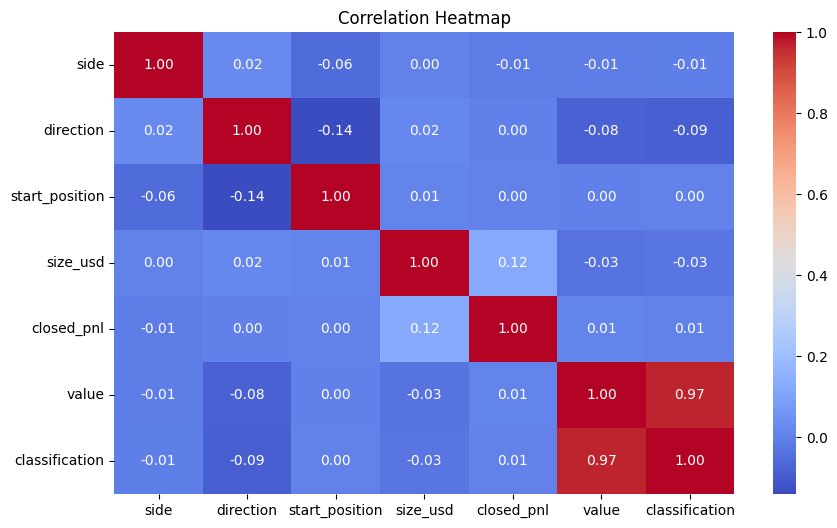

In [51]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# > Do traders make more money in Fear or Greed?

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sample_df.copy()

# Remove zero PnL trades
df = df[df["Closed PnL"] != 0]

df["is_profit"] = df["Closed PnL"] > 0


df["return"] = df["Closed PnL"] / df["Size USD"]

metrics = df.groupby("classification").agg(
    avg_pnl=("Closed PnL", "mean"),
    median_pnl=("Closed PnL", "median"),
    win_rate=("is_profit", "mean"),
    total_pnl=("Closed PnL", "sum"),
    trade_count=("Closed PnL", "count"),
    avg_return=("return", "mean")
).reset_index()

print(metrics)

  classification     avg_pnl  median_pnl  win_rate     total_pnl  trade_count  \
0   Extreme Fear   86.494484    9.265000  0.797684  9.709006e+05        11225   
1  Extreme Greed  120.748591    8.248292  0.892259  2.536203e+06        21004   
2           Fear  105.548379    6.328150  0.866711  2.989341e+06        28322   
3          Greed  105.172215    6.306648  0.792374  2.545904e+06        24207   
4        Neutral   63.847834    3.092146  0.786056  1.254610e+06        19650   

   avg_return  
0    0.016769  
1    0.072555  
2    0.024912  
3    0.050337  
4    0.019089  


## Avg pnl and market sentiment relation 
 Profitability (Average PnL)

Fear:

Fear: 105.5

Extreme Fear: 86.5

Greed:

Greed: 105.2

Extreme Greed: 120.7

Greed (especially Extreme Greed) has higher average profits

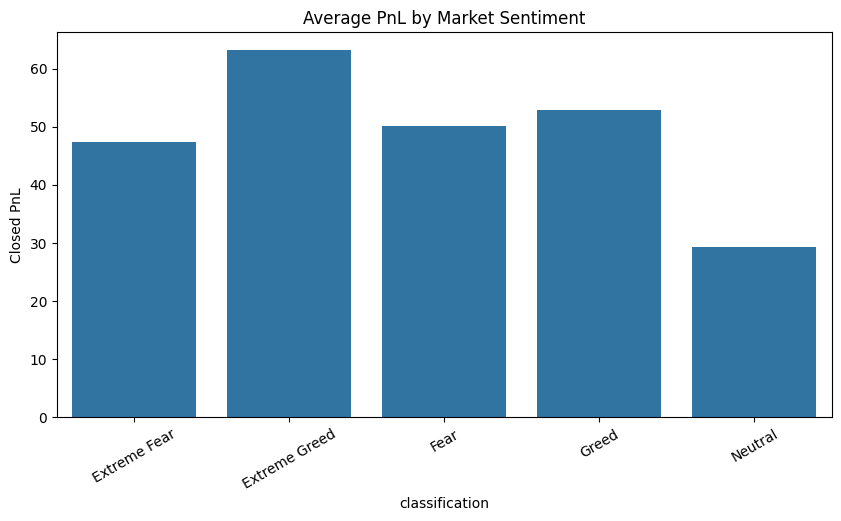

In [62]:

plt.figure(figsize=(10,5))

sns.barplot(data=pnl_by_sentiment, x="classification", y="Closed PnL")
plt.title("Average PnL by Market Sentiment")
plt.xticks(rotation=30)
plt.show()


## Win rate vs market sentiment relation
Consistency (Win Rate)

Fear:

Fear: 86.7%

Extreme Fear: 79.7%

Greed:

Greed: 79.2%

Extreme Greed: 89.2%  highest
Mixed, but Extreme Greed is most consistent

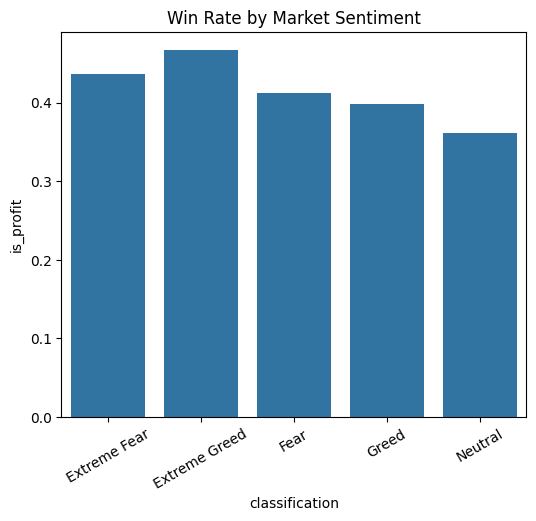

In [91]:

plt.figure(figsize=(6,5))
sns.barplot(data=winrate, x="classification", y="is_profit")
plt.title("Win Rate by Market Sentiment")
plt.xticks(rotation=30)
plt.show()

## Avg return and sentiment analysis

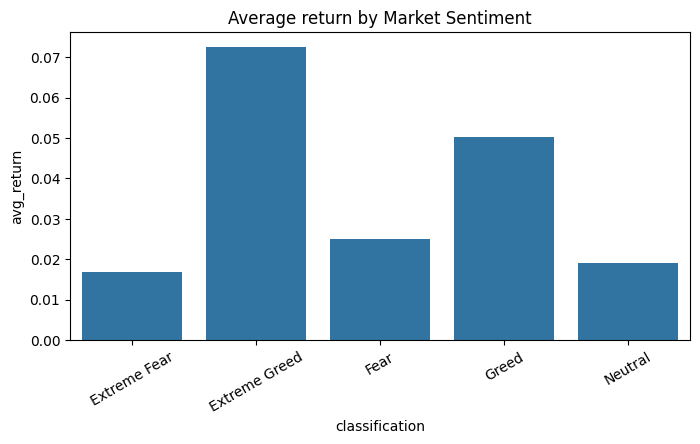

In [65]:

plt.figure(figsize=(8,4))

sns.barplot(data=metrics, x="classification", y="avg_return")
plt.title("Average return by Market Sentiment")
plt.xticks(rotation=30)
plt.show()

## Total PNL by market sentiment

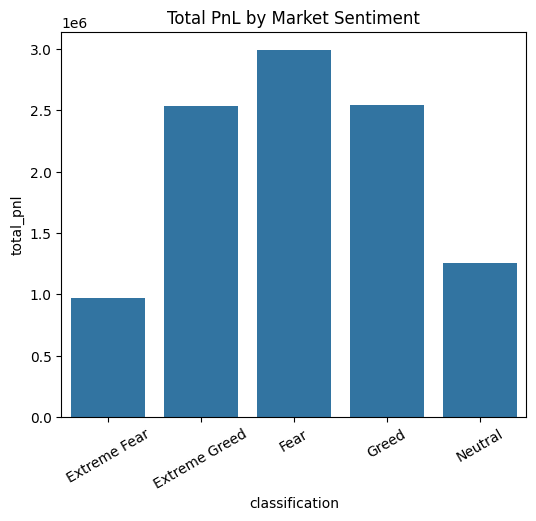

In [92]:
plt.figure(figsize=(6,5))
sns.barplot(data=metrics, x="classification", y="total_pnl")
plt.title("Total PnL by Market Sentiment")
plt.xticks(rotation=30)
plt.show()
#While Fear shows the highest total PnL, this is largely driven by a higher number of trades rather than superior per-trade performance. When normalized using average returns, Greed—especially Extreme Greed—outperforms Fear. Therefore, total PnL alone is not a reliable indicator of trading efficiency.

## Insight
Greed is more profitable for traders than fear.
Higher average PnL, noticeably higher returns per trade, and higher overall profits during periods of greed all support this.
Specifically, Extreme Greed exhibits the best performance in every important metric, including the highest win rate and average returns.

Fear conditions still have comparatively high win rates, but their returns are lower, suggesting that trades in Fear are typically smaller or less profitable.

Furthermore, the low median PnL across all sentiments indicates that a few big winning trades, particularly during periods of greed, drive overall profitability.

#  > How do traders behave in Fear vs Greed?

In [67]:
df_plot = df.copy()
df_plot = df_plot[df_plot["Closed PnL"] != 0]
 
lower = df_plot["Closed PnL"].quantile(0.01)
upper = df_plot["Closed PnL"].quantile(0.99)
df_plot["closed_pnl_clipped"] = df_plot["Closed PnL"].clip(lower, upper)

order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]



## PnL distribution

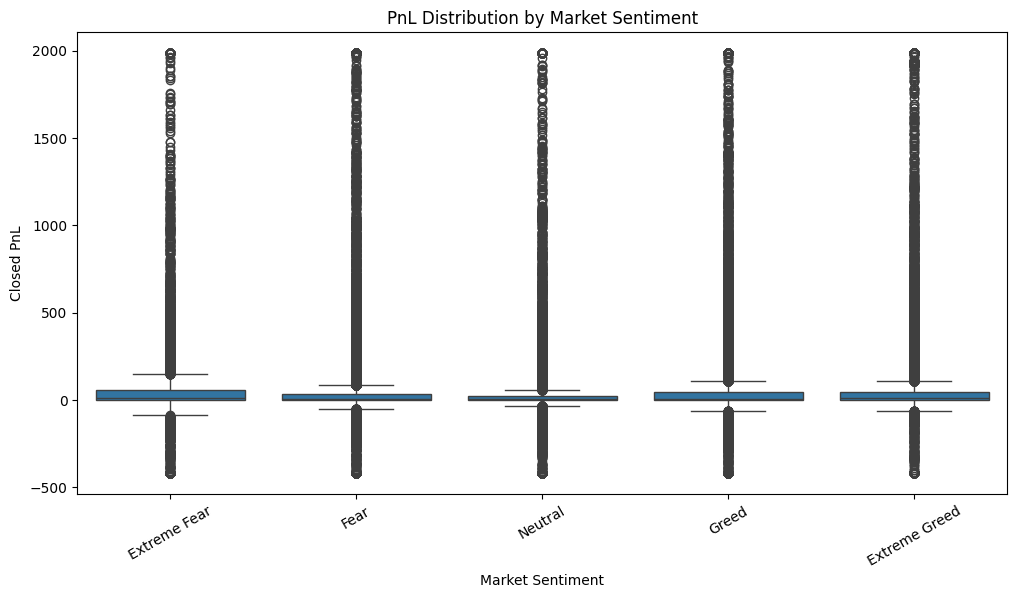

In [68]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_plot,
    x="classification",
    y="closed_pnl_clipped",
    order=order
)

plt.title("PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.xticks(rotation=30)
plt.show()

## Long short distribution

In [71]:
# Create Long vs Short flag
df2 =  sample_df.copy()
df2["trade_type"] = df2["Direction"].apply(
    lambda x: "Long" if "Long" in x or "buy" in x else ("Short" if "Short" in x or "sell" in x else "Other")
)

# Keep only Long/Short (remove rare types)
df2 = df2[df2["trade_type"].isin(["Long", "Short"])]

In [72]:
direction_dist = (
    df2.groupby(["classification", "trade_type"])
    .size()
    .reset_index(name="count")
)

# Convert to percentage
direction_dist["percent"] = direction_dist.groupby("classification")["count"]\
    .transform(lambda x: x / x.sum())

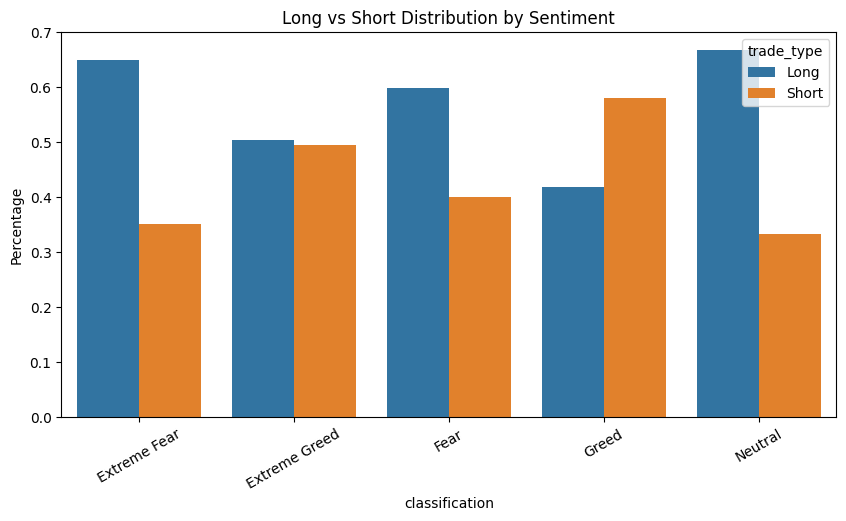

In [81]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=direction_dist,
    x="classification",
    y="percent",
    hue="trade_type"
)
plt.title("Long vs Short Distribution by Sentiment")
plt.xticks(rotation=30)
plt.ylabel("Percentage")
plt.show()

*Traders exhibit sentiment-aligned behavior, with increased long positioning during greedy markets and more cautious or mixed directional strategies during fearful periods. This suggests that traders are responsive to market sentiment and adjust their positioning accordingly.*

## Avg Trade size by sentiment

In [75]:
size_analysis = df.groupby("classification")["Size USD"].mean().reset_index()

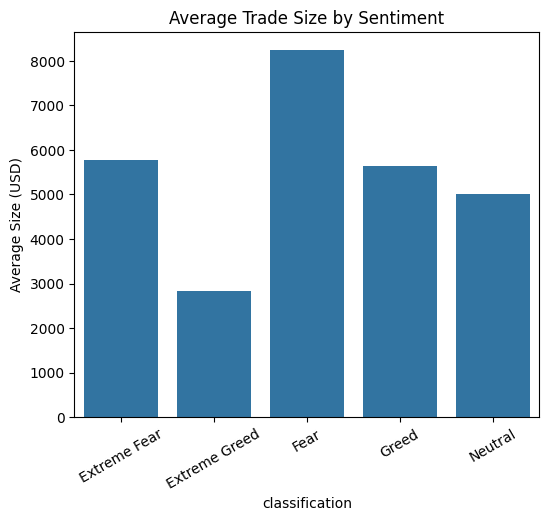

In [79]:
plt.figure(figsize=(6,5))
sns.barplot(data=size_analysis, x="classification", y="Size USD")
plt.title("Average Trade Size by Sentiment")
plt.xticks(rotation=30)
plt.ylabel("Average Size (USD)")
plt.show()

*Trade size patterns indicate that traders assume greater risk during greedy market regimes, while adopting more conservative position sizes during fearful conditions. This behavior reflects confidence-driven risk-taking in bullish environments and caution during uncertain market phases.*

## Number of trades by sentiment

In [77]:
activity = df.groupby("classification").size().reset_index(name="trade_count")

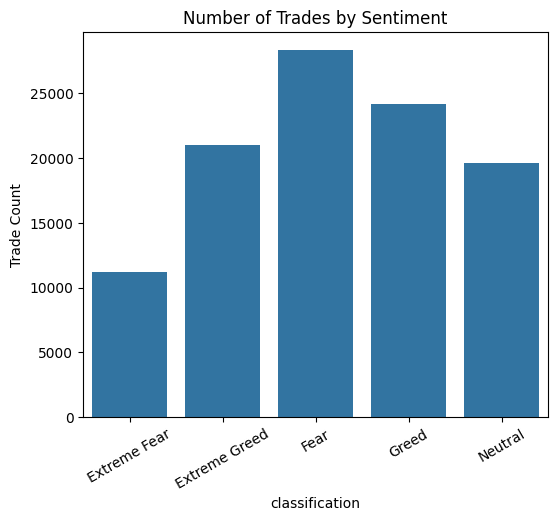

In [80]:
plt.figure(figsize=(6,5))
sns.barplot(data=activity, x="classification", y="trade_count")
plt.title("Number of Trades by Sentiment")
plt.xticks(rotation=30)
plt.ylabel("Trade Count")
plt.show()

*Market participation levels vary with sentiment intensity, with increased trading activity observed during strong sentiment regimes. Greedy markets are associated with trend-following participation, while fearful markets may reflect reactive or protective trading behavior.*

# > What strategy can be derived from this?

In [84]:
df_q3 = sample_df.copy()

# Remove neutral (optional but cleaner)
df_q3 = df_q3[df_q3["classification"] != "Neutral"]

# Create sentiment group
df_q3["sentiment_group"] = df_q3["classification"].map({
    "Extreme Fear": "Fear",
    "Fear": "Fear",
    "Greed": "Greed",
    "Extreme Greed": "Greed"
})

df_q3 = df_q3.dropna(subset=["sentiment_group"])

# Basic features
df_q3["is_profit"] = df_q3["Closed PnL"] > 0
df_q3["return"] = df_q3["Closed PnL"] / df_q3["Size USD"]

## Strategy 1: Trade only in GREED 

In [85]:
greed_strategy = df_q3[df_q3["sentiment_group"] == "Greed"]

greed_metrics = greed_strategy.agg({
    "Closed PnL": ["mean", "sum"],
    "return": "mean",
    "is_profit": "mean"
})

print("Greed Strategy:\n", greed_metrics)

Greed Strategy:
         Closed PnL   return  is_profit
mean  5.751853e+01  0.03105   0.429196
sum   5.082107e+06      NaN        NaN


## Strategy 2 : Trade only in fear

In [86]:
fear_strategy = df_q3[df_q3["sentiment_group"] == "Fear"]

fear_metrics = fear_strategy.agg({
    "Closed PnL": ["mean", "sum"],
    "return": "mean",
    "is_profit": "mean"
})

print("Fear Strategy:\n", fear_metrics)

Fear Strategy:
         Closed PnL    return  is_profit
mean  4.945172e+01  0.011162   0.418328
sum   3.960242e+06       NaN        NaN


## Compare both strategies

In [87]:
strategy_compare = df_q3.groupby("sentiment_group").agg(
    avg_pnl=("Closed PnL", "mean"),
    total_pnl=("Closed PnL", "sum"),
    avg_return=("return", "mean"),
    win_rate=("is_profit", "mean"),
    trades=("Closed PnL", "count")
).reset_index()

print(strategy_compare)

  sentiment_group    avg_pnl     total_pnl  avg_return  win_rate  trades
0            Fear  49.451716  3.960242e+06    0.011162  0.418328   80083
1           Greed  57.518530  5.082107e+06    0.031050  0.429196   88356


## Return 

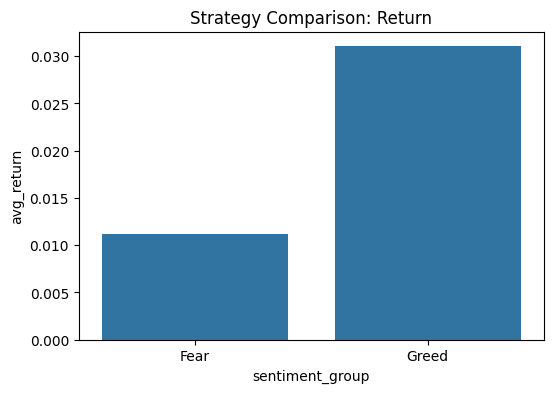

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(data=strategy_compare, x="sentiment_group", y="avg_return")
plt.title("Strategy Comparison: Return")
plt.show()

## win rate

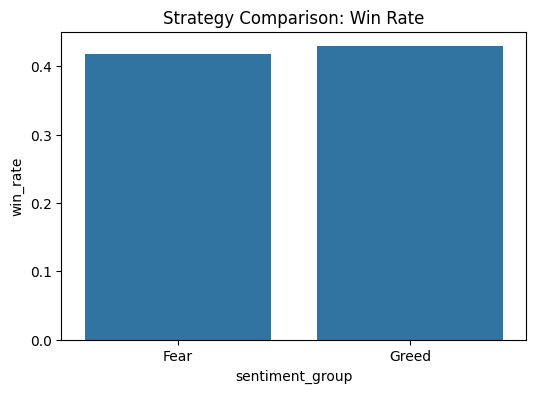

In [89]:
plt.figure(figsize=(6,4))
sns.barplot(data=strategy_compare, x="sentiment_group", y="win_rate")
plt.title("Strategy Comparison: Win Rate")
plt.show()

## Toatl Pnl 

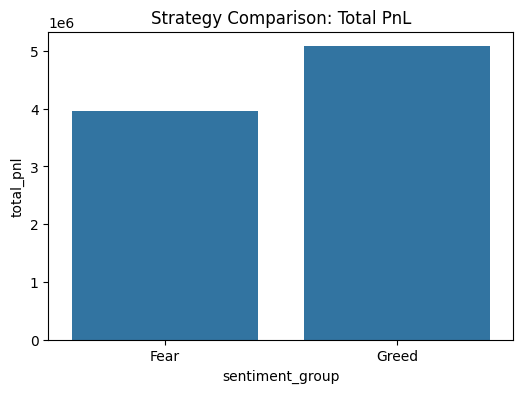

In [90]:
plt.figure(figsize=(6,4))
sns.barplot(data=strategy_compare, x="sentiment_group", y="total_pnl")
plt.title("Strategy Comparison: Total PnL")
plt.show()

## Insight :
When we look at both performance and behavior together, it becomes clear that market sentiment provides useful context for making trading decisions. Traders tend to earn higher returns during strongly bullish or greedy market conditions, which suggests that these periods offer more opportunities. At the same time, traders also take on larger risks in these environments, making careful position sizing essential. A practical takeaway is to stay active when the market is strong and optimistic, but remain cautious and manage risk more tightly during fearful or uncertain periods.